In [1]:
import pandas as pd

# EIA Weekly Petroleum Status Report - inventarios Cushing
# Fuente directa, gratis, sin API key
url = "https://api.eia.gov/v2/petroleum/stoc/wstk/data/?api_key=DEMO_KEY&frequency=weekly&data[0]=value&facets[series][]=WCSSTUS1&start=2020-01-01&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"

df_eia = pd.read_json(url)
print(df_eia.head())

                                                     response  \
total                                                     321   
dateFormat                                         YYYY-MM-DD   
frequency                                              weekly   
data        [{'period': '2026-02-20', 'duoarea': 'NUS', 'a...   
command                                                   NaN   

                                  request apiVersion ExcelAddInVersion  
total                                 NaN     2.1.12             2.1.0  
dateFormat                            NaN     2.1.12             2.1.0  
frequency                             NaN     2.1.12             2.1.0  
data                                  NaN     2.1.12             2.1.0  
command     /v2/petroleum/stoc/wstk/data/     2.1.12             2.1.0  


In [5]:
import pandas as pd
import requests

url = "https://api.eia.gov/v2/petroleum/stoc/wstk/data/?api_key=DEMO_KEY&frequency=weekly&data[0]=value&facets[series][]=WCRSTUS1&start=2020-01-01&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"

response = requests.get(url)
json_data = response.json()

df_eia = pd.DataFrame(json_data['response']['data'])

# Limpiar a lo esencial
df_eia_clean = df_eia[['period', 'value']].copy()
df_eia_clean.columns = ['date', 'inventory_mbbl']
df_eia_clean['date'] = pd.to_datetime(df_eia_clean['date'])
df_eia_clean = df_eia_clean.sort_values('date').reset_index(drop=True)

print(f"Registros: {len(df_eia_clean)}")
print(f"Cobertura: {df_eia_clean['date'].min()} a {df_eia_clean['date'].max()}")
print(df_eia_clean.tail(10))

Registros: 321
Cobertura: 2020-01-03 00:00:00 a 2026-02-20 00:00:00
          date inventory_mbbl
311 2025-12-19         837793
312 2025-12-26         836107
313 2026-01-02         832520
314 2026-01-09         836125
315 2026-01-16         840533
316 2026-01-23         838753
317 2026-01-30         835512
318 2026-02-06         844041
319 2026-02-13         835256
320 2026-02-20         851245


In [7]:
# Convertir a numérico primero
df_eia_clean['inventory_mbbl'] = pd.to_numeric(df_eia_clean['inventory_mbbl'], errors='coerce')

# Ahora sí calcular los cambios
df_eia_clean['inventory_change'] = df_eia_clean['inventory_mbbl'].diff()
df_eia_clean['news_direction'] = df_eia_clean['inventory_change'].apply(
    lambda x: 'bearish' if x > 0 else 'bullish'
)

print(df_eia_clean[['date', 'inventory_mbbl', 'inventory_change', 'news_direction']].tail(10))

          date  inventory_mbbl  inventory_change news_direction
311 2025-12-19          837793            1205.0        bearish
312 2025-12-26          836107           -1686.0        bullish
313 2026-01-02          832520           -3587.0        bullish
314 2026-01-09          836125            3605.0        bearish
315 2026-01-16          840533            4408.0        bearish
316 2026-01-23          838753           -1780.0        bullish
317 2026-01-30          835512           -3241.0        bullish
318 2026-02-06          844041            8529.0        bearish
319 2026-02-13          835256           -8785.0        bullish
320 2026-02-20          851245           15989.0        bearish


In [8]:
import yfinance as yf
import pandas as pd
import numpy as np

# Cargar datos horarios WTI
cl = yf.download("CL=F", period="2y", interval="1h")
cl.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
cl.index = cl.index.tz_convert('US/Eastern')  # Alinear timezone con EIA

# Construir features de liquidez
cl['log_volume'] = np.log(cl['Volume'] + 1)
cl['price_range'] = cl['High'] - cl['Low']
cl['log_return'] = np.log(cl['Close'] / cl['Close'].shift(1))
cl['amihud'] = cl['log_return'].abs() / (cl['Volume'] + 1)

# Alinear fechas EIA con yfinance
# EIA publica miércoles 10:30 AM ET
df_eia_clean['datetime_et'] = pd.to_datetime(df_eia_clean['date']) + pd.Timedelta(hours=10, minutes=30)
df_eia_clean['datetime_et'] = df_eia_clean['datetime_et'].dt.tz_localize('US/Eastern')

# Ventana de evento: 4 horas antes y 8 horas después de cada reporte
windows = []
for _, event in df_eia_clean.iterrows():
    t = event['datetime_et']
    window = cl.loc[t - pd.Timedelta(hours=4) : t + pd.Timedelta(hours=8)].copy()
    if len(window) > 0:
        window['event_date'] = event['date']
        window['inventory_change'] = event['inventory_change']
        window['news_direction'] = event['news_direction']
        window['hours_from_event'] = (window.index - t).total_seconds() / 3600
        windows.append(window)

df_events = pd.concat(windows)
print(f"Ventanas de evento construidas: {df_events['event_date'].nunique()}")
print(f"Total registros: {len(df_events)}")
print(df_events[['hours_from_event', 'log_volume', 'price_range', 'news_direction']].head(15))

[*********************100%***********************]  1 of 1 completed

Ventanas de evento construidas: 101
Total registros: 993
                           hours_from_event  log_volume  price_range  \
Datetime                                                               
2024-03-08 07:00:00-05:00              -3.5    9.618336     0.360001   
2024-03-08 08:00:00-05:00              -2.5   10.248211     0.599998   
2024-03-08 09:00:00-05:00              -1.5   10.436319     0.549995   
2024-03-08 10:00:00-05:00              -0.5   10.345992     0.550003   
2024-03-08 11:00:00-05:00               0.5   10.691649     1.029999   
2024-03-08 12:00:00-05:00               1.5   10.106755     0.420006   
2024-03-08 13:00:00-05:00               2.5    9.886341     0.440002   
2024-03-08 14:00:00-05:00               3.5   10.453803     0.470001   
2024-03-08 15:00:00-05:00               4.5    9.134970     0.150002   
2024-03-08 16:00:00-05:00               5.5    8.021913     0.190002   
2024-03-15 07:00:00-04:00              -3.5    8.499640     0.269997   
2024-03

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np

# Cargar datos horarios WTI
cl = yf.download("CL=F", period="2y", interval="1h")
cl.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
cl.index = cl.index.tz_convert('US/Eastern')  # Alinear timezone con EIA

# Construir features de liquidez
cl['log_volume'] = np.log(cl['Volume'] + 1)
cl['price_range'] = cl['High'] - cl['Low']
cl['log_return'] = np.log(cl['Close'] / cl['Close'].shift(1))
cl['amihud'] = cl['log_return'].abs() / (cl['Volume'] + 1)

# Alinear fechas EIA con yfinance
# EIA publica miércoles 10:30 AM ET
df_eia_clean['datetime_et'] = pd.to_datetime(df_eia_clean['date']) + pd.Timedelta(hours=10, minutes=30)
df_eia_clean['datetime_et'] = df_eia_clean['datetime_et'].dt.tz_localize('US/Eastern')

# Ventana de evento: 4 horas antes y 8 horas después de cada reporte
windows = []
for _, event in df_eia_clean.iterrows():
    t = event['datetime_et']
    window = cl.loc[t - pd.Timedelta(hours=4) : t + pd.Timedelta(hours=8)].copy()
    if len(window) > 0:
        window['event_date'] = event['date']
        window['inventory_change'] = event['inventory_change']
        window['news_direction'] = event['news_direction']
        window['hours_from_event'] = (window.index - t).total_seconds() / 3600
        windows.append(window)

df_events = pd.concat(windows)
print(f"Ventanas de evento construidas: {df_events['event_date'].nunique()}")
print(f"Total registros: {len(df_events)}")
print(df_events[['hours_from_event', 'log_volume', 'price_range', 'news_direction']].head(15))

[*********************100%***********************]  1 of 1 completed

Ventanas de evento construidas: 101
Total registros: 993
                           hours_from_event  log_volume  price_range  \
Datetime                                                               
2024-03-08 07:00:00-05:00              -3.5    9.618336     0.360001   
2024-03-08 08:00:00-05:00              -2.5   10.248211     0.599998   
2024-03-08 09:00:00-05:00              -1.5   10.436319     0.549995   
2024-03-08 10:00:00-05:00              -0.5   10.345992     0.550003   
2024-03-08 11:00:00-05:00               0.5   10.691649     1.029999   
2024-03-08 12:00:00-05:00               1.5   10.106755     0.420006   
2024-03-08 13:00:00-05:00               2.5    9.886341     0.440002   
2024-03-08 14:00:00-05:00               3.5   10.453803     0.470001   
2024-03-08 15:00:00-05:00               4.5    9.134970     0.150002   
2024-03-08 16:00:00-05:00               5.5    8.021913     0.190002   
2024-03-15 07:00:00-04:00              -3.5    8.499640     0.269997   
2024-03

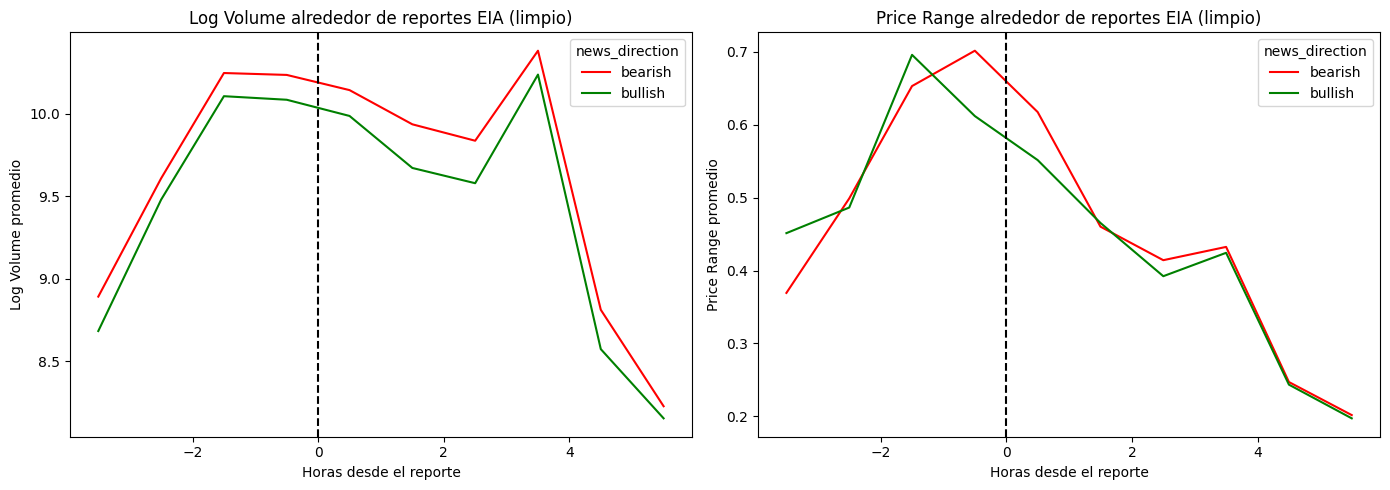

T-test price_range bearish vs bullish:
  t = 0.407, p = 0.6838
  Diferencia NO significativa ❌


In [12]:
# Limpiar artefactos - solo horas con suficientes observaciones
counts = df_events.groupby('hours_from_event')['log_volume'].count()
valid_hours = counts[counts >= 20].index  # Mínimo 20 eventos por hora

df_clean = df_events[df_events['hours_from_event'].isin(valid_hours)]

# Recrear gráficos con datos limpios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot = df_clean.groupby(['hours_from_event', 'news_direction'])['log_volume'].mean().unstack()
pivot2 = df_clean.groupby(['hours_from_event', 'news_direction'])['price_range'].mean().unstack()

pivot.plot(ax=axes[0], color={'bearish': 'red', 'bullish': 'green'})
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('Log Volume alrededor de reportes EIA (limpio)')
axes[0].set_xlabel('Horas desde el reporte')
axes[0].set_ylabel('Log Volume promedio')

pivot2.plot(ax=axes[1], color={'bearish': 'red', 'bullish': 'green'})
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Price Range alrededor de reportes EIA (limpio)')
axes[1].set_xlabel('Horas desde el reporte')
axes[1].set_ylabel('Price Range promedio')

plt.tight_layout()
plt.savefig('event_study_clean.png', dpi=150)
plt.show()

# Test estadístico básico - ¿es real la diferencia?
from scipy import stats

bearish_range = df_clean[df_clean['news_direction']=='bearish']['price_range']
bullish_range = df_clean[df_clean['news_direction']=='bullish']['price_range']

t_stat, p_value = stats.ttest_ind(bearish_range, bullish_range)
print(f"T-test price_range bearish vs bullish:")
print(f"  t = {t_stat:.3f}, p = {p_value:.4f}")
print(f"  {'Diferencia significativa ✅' if p_value < 0.05 else 'Diferencia NO significativa ❌'}")

In [13]:
from scipy import stats

# Testear solo la ventana de reacción inmediata (horas 0 a +2)
reaction = df_clean[df_clean['hours_from_event'].between(0, 2)]

bearish_vol = reaction[reaction['news_direction']=='bearish']['log_volume']
bullish_vol = reaction[reaction['news_direction']=='bullish']['log_volume']
bearish_range = reaction[reaction['news_direction']=='bearish']['price_range']
bullish_range = reaction[reaction['news_direction']=='bullish']['price_range']

print("=== VENTANA DE REACCIÓN (horas 0 a +2) ===")
t1, p1 = stats.ttest_ind(bearish_vol, bullish_vol)
print(f"Log Volume:   t={t1:.3f}, p={p1:.4f} {'✅' if p1<0.05 else '❌'}")

t2, p2 = stats.ttest_ind(bearish_range, bullish_range)
print(f"Price Range:  t={t2:.3f}, p={p2:.4f} {'✅' if p2<0.05 else '❌'}")

# Testear también la magnitud del shock - no la dirección
# ¿Los shocks grandes (independiente de dirección) generan más reacción?
df_clean['shock_magnitude'] = df_clean['inventory_change'].abs()
df_clean['shock_quartile'] = pd.qcut(
    df_clean.groupby('event_date')['shock_magnitude'].transform('first'),
    q=2, labels=['small_shock', 'large_shock']
)

reaction2 = df_clean[df_clean['hours_from_event'].between(0, 2)]
print("\n=== SHOCKS GRANDES vs PEQUEÑOS ===")
small = reaction2[reaction2['shock_quartile']=='small_shock']['price_range']
large = reaction2[reaction2['shock_quartile']=='large_shock']['price_range']
t3, p3 = stats.ttest_ind(small, large)
print(f"Price Range small vs large shock: t={t3:.3f}, p={p3:.4f} {'✅' if p3<0.05 else '❌'}")

print("\n=== MEDIAS ===")
print(reaction2.groupby('news_direction')[['log_volume','price_range']].mean())
print(reaction2.groupby('shock_quartile')[['log_volume','price_range']].mean())

=== VENTANA DE REACCIÓN (horas 0 a +2) ===
Log Volume:   t=2.192, p=0.0296 ✅
Price Range:  t=0.819, p=0.4139 ❌

=== SHOCKS GRANDES vs PEQUEÑOS ===
Price Range small vs large shock: t=-0.083, p=0.9339 ❌

=== MEDIAS ===
                log_volume  price_range
news_direction                         
bearish          10.038712     0.538804
bullish           9.828246     0.508396
                log_volume  price_range
shock_quartile                         
small_shock       9.899289     0.520999
large_shock       9.953333     0.524082


In [14]:
import statsmodels.formula.api as smf

# Preparar dataset para regresión
reg_data = df_clean[df_clean['hours_from_event'].between(0, 2)].copy()
reg_data['is_bearish'] = (reg_data['news_direction'] == 'bearish').astype(int)
reg_data['shock_size'] = reg_data.groupby('event_date')['shock_magnitude'].transform('first')
reg_data['shock_size_norm'] = (reg_data['shock_size'] - reg_data['shock_size'].mean()) / reg_data['shock_size'].std()

# Modelo 1 — solo dirección
m1 = smf.ols('log_volume ~ is_bearish', data=reg_data).fit()

# Modelo 2 — dirección + magnitud
m2 = smf.ols('log_volume ~ is_bearish + shock_size_norm', data=reg_data).fit()

# Modelo 3 — interacción (¿el efecto de dirección depende de la magnitud?)
m3 = smf.ols('log_volume ~ is_bearish * shock_size_norm', data=reg_data).fit()

print("=== MODELO 1 — Solo dirección ===")
print(f"  is_bearish: coef={m1.params['is_bearish']:.3f}, p={m1.pvalues['is_bearish']:.4f}")
print(f"  R²={m1.rsquared:.4f}")

print("\n=== MODELO 2 — Dirección + Magnitud ===")
print(f"  is_bearish: coef={m2.params['is_bearish']:.3f}, p={m2.pvalues['is_bearish']:.4f}")
print(f"  shock_size: coef={m2.params['shock_size_norm']:.3f}, p={m2.pvalues['shock_size_norm']:.4f}")
print(f"  R²={m2.rsquared:.4f}")

print("\n=== MODELO 3 — Con interacción ===")
print(f"  is_bearish: coef={m3.params['is_bearish']:.3f}, p={m3.pvalues['is_bearish']:.4f}")
print(f"  shock_size: coef={m3.params['shock_size_norm']:.3f}, p={m3.pvalues['shock_size_norm']:.4f}")
print(f"  interacción: coef={m3.params['is_bearish:shock_size_norm']:.3f}, p={m3.pvalues['is_bearish:shock_size_norm']:.4f}")
print(f"  R²={m3.rsquared:.4f}")

=== MODELO 1 — Solo dirección ===
  is_bearish: coef=0.210, p=0.0296
  R²=0.0239

=== MODELO 2 — Dirección + Magnitud ===
  is_bearish: coef=0.217, p=0.0299
  shock_size: coef=-0.014, p=0.7820
  R²=0.0243

=== MODELO 3 — Con interacción ===
  is_bearish: coef=0.216, p=0.0308
  shock_size: coef=-0.028, p=0.6877
  interacción: coef=0.029, p=0.7697
  R²=0.0247
